In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from PIL import Image
import cv2

In [2]:
train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("validation.csv")
test_df = pd.read_csv("test.csv")

In [3]:
class_counts = train_df["disease"].value_counts()
class_counts

disease
Melanocytic Nevus       4693
Melanoma                 779
Benign Keratosis         769
Basal Cell Carcinoma     360
Actinic Keratosis        229
Vascular Lesion           99
Dermatofibroma            81
Name: count, dtype: int64

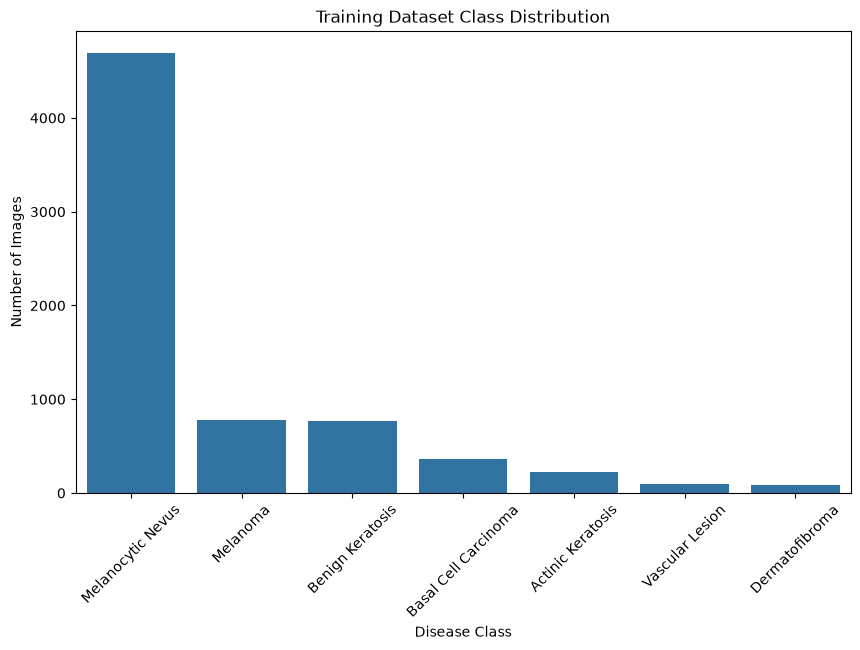

In [4]:
plt.figure(figsize=(10,6))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)
plt.xticks(rotation=45)
plt.xlabel("Disease Class")
plt.ylabel("Number of Images")
plt.title("Training Dataset Class Distribution")
plt.show()

In [5]:
image_path = train_df.iloc[0]["path"]
img = Image.open(image_path)

In [6]:
img_array = np.array(img)

In [7]:
img_array.shape

(450, 600, 3)

In [8]:
print("Minimum pixel value:", img_array.min())
print("Maximum pixel value:", img_array.max())

Minimum pixel value: 7
Maximum pixel value: 255


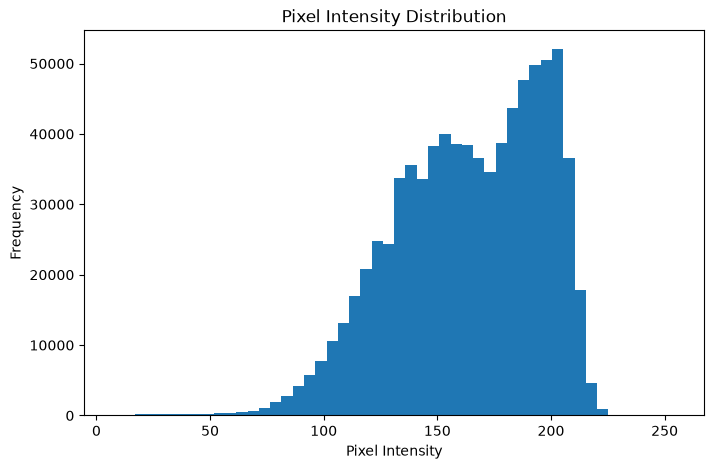

In [9]:
plt.figure(figsize=(8,5))
plt.hist(
    img_array.ravel(),
    bins=50
)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution")
plt.show()

In [10]:
pixel_values = []
for path in train_df["path"].sample(100):
    img = Image.open(path)
    img_array = np.array(img)
    pixel_values.extend(
        img_array.ravel()
    )

In [12]:
IMG_HEIGHT = 224
IMG_WIDTH = 224
def load_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    return image
sample_path = train_df.iloc[0]["path"]
image = load_image(sample_path)
image = image / 255.0

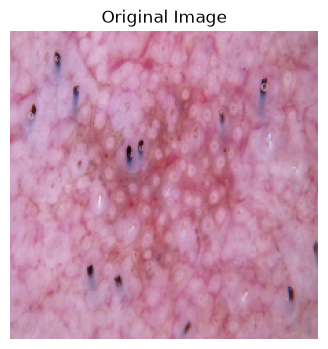

In [13]:
plt.figure(figsize=(4,4))
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0108136].


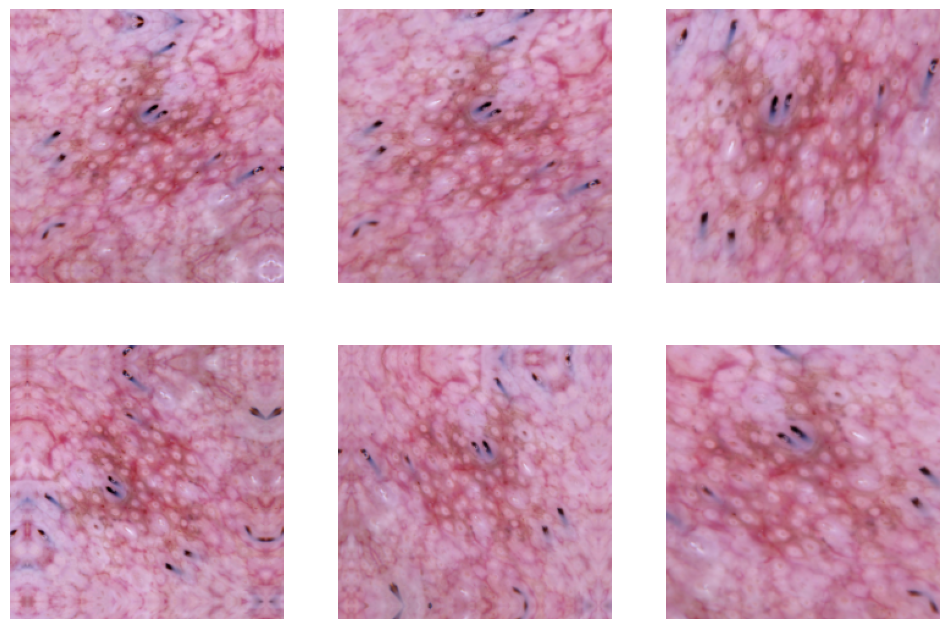

In [14]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])
plt.figure(figsize=(12,8))
for i in range(6):
    augmented_image = data_augmentation(
        tf.expand_dims(image, axis=0)
    )
    plt.subplot(2,3,i+1)
    plt.imshow(
        augmented_image[0]
    )
    plt.axis("off")
plt.show()

In [15]:
class_image_size = {}
for disease in train_df["disease"].unique():
    sample = train_df[
        train_df["disease"] == disease
    ].iloc[0]
    img = Image.open(sample["path"])
    class_image_size[disease] = img.size
class_image_size

{'Actinic Keratosis': (600, 450),
 'Basal Cell Carcinoma': (600, 450),
 'Melanocytic Nevus': (600, 450),
 'Melanoma': (600, 450),
 'Benign Keratosis': (600, 450),
 'Vascular Lesion': (600, 450),
 'Dermatofibroma': (600, 450)}

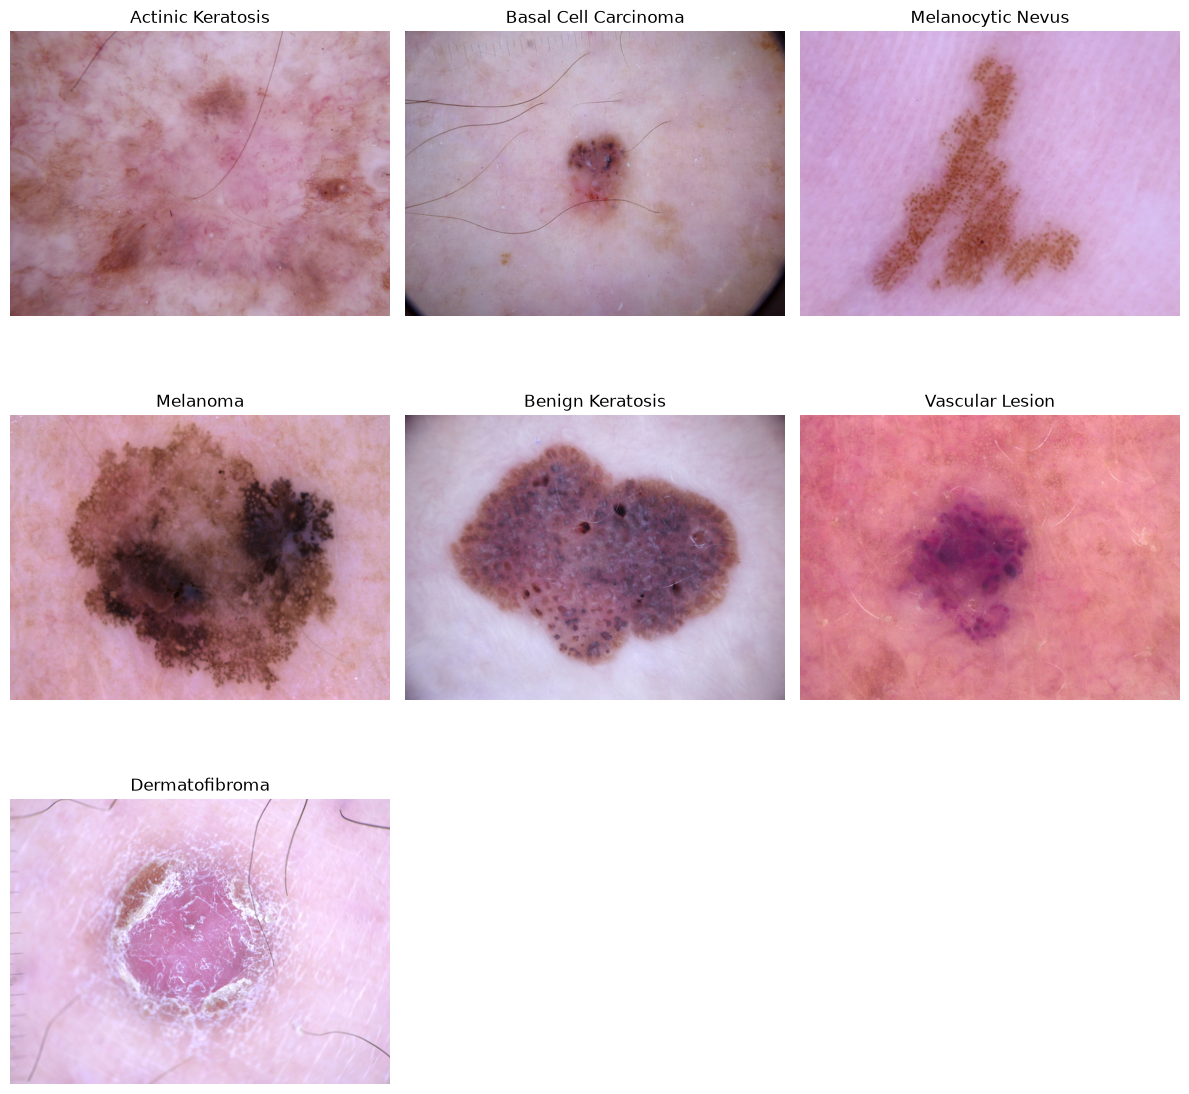

In [16]:
classes = train_df["disease"].unique()
plt.figure(figsize=(12,12))
for i, disease in enumerate(classes):
    sample = train_df[
        train_df["disease"] == disease
    ].sample(1)
    img = Image.open(
        sample.iloc[0]["path"]
    )
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(disease)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [17]:
brightness = []
for path in train_df["path"].sample(200):
    img = Image.open(path)
    img_array = np.array(img)
    brightness.append(
        img_array.mean()
    )

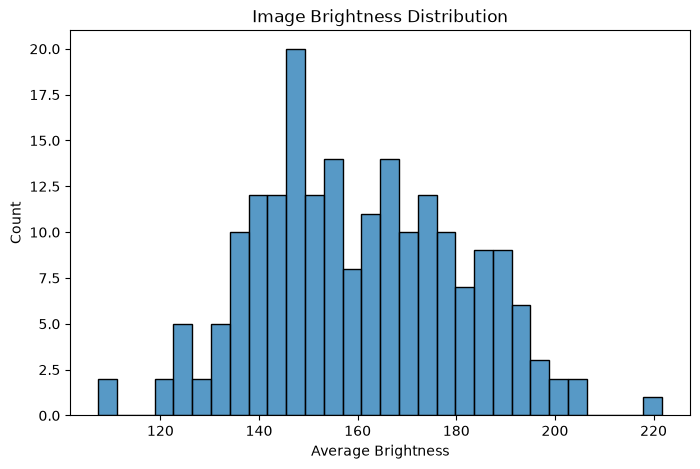

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(
    brightness,
    bins=30
)
plt.xlabel("Average Brightness")
plt.title("Image Brightness Distribution")
plt.show()

In [23]:
sharpness = []
for path in train_df["path"].sample(100):
    img = cv2.imread(path)
    gray = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2GRAY
    )
    variance = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()
    sharpness.append(variance)

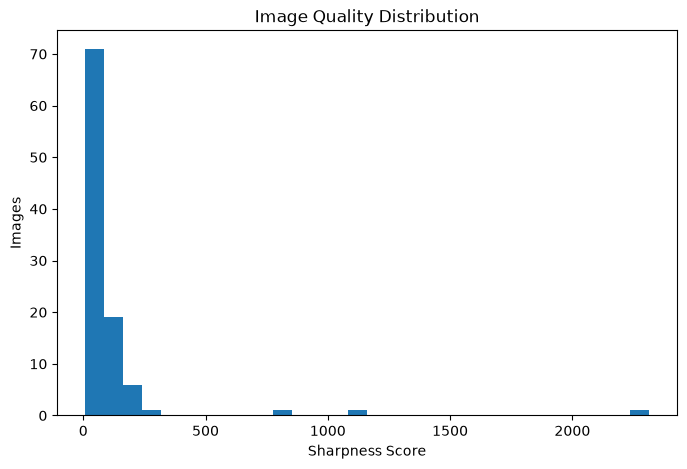

In [24]:
plt.figure(figsize=(8,5))
plt.hist(
    sharpness,
    bins=30
)
plt.xlabel("Sharpness Score")
plt.ylabel("Images")
plt.title("Image Quality Distribution")
plt.show()